<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio5/pytorch_turbina_gas_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Redes Neuronales en PyTorch para Regresion
## Prediccion de Emisiones de CO — Gas Turbine Emission Dataset

**Autora:** Helen Janko Sanga  
**Dataset:** Gas Turbine CO and NOx Emission Data Set — UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set

---

## Objetivo del cuadernillo

Este cuadernillo integra y aplica los tres laboratorios anteriores de PyTorch a un problema real de regresion:

- **Cuadernillo 02 — Redes Neuronales en PyTorch:** Definicion de modelos con `torch.nn.Module`, uso de funciones de perdida (`criterion`) y del optimizador SGD (`torch.optim.SGD`), y el bucle completo de entrenamiento con `model.train()`, `optimizer.zero_grad()`, `loss.backward()` y `optimizer.step()`.
- **Cuadernillo 03 — Datasets en PyTorch:** Creacion de una clase `Dataset` personalizada y uso del `DataLoader` para iterar los datos en mini-batches de forma eficiente.
- **Cuadernillo 04 — Guardado de Modelos:** La funcion `fit` que registra `train_loss`, `val_loss`, `train_mse` y `val_mse` por epoca, guarda el `state_dict` cuando la `val_loss` mejora (checkpoint), y carga el mejor modelo al finalizar.

Todo lo anterior se aplica a un **problema de regresion**: predecir las emisiones de Monoxido de Carbono (CO) de una turbina de gas en Turquia, a partir de variables ambientales y operativas medidas por sensores.

---

## Descripcion del Dataset

El dataset contiene mediciones de sensores instalados en una turbina de gas real, registradas entre los anos 2011 y 2015.

| Caracteristica | Valor |
|---|---|
| Numero de instancias | 36,733 |
| Numero de features de entrada | 9 variables de sensores operativos |
| Variable objetivo | CO — Monoxido de Carbono (mg/m3) |
| Anos cubiertos | 2011 a 2015 |

**Variables del dataset:**

| Variable | Descripcion | Unidad |
|---|---|---|
| AT | Temperatura Ambiente | C |
| AP | Presion Ambiente | mbar |
| AH | Humedad Relativa Ambiente | % |
| AFDP | Diferencia de Presion del Filtro de Aire | mbar |
| GTEP | Presion de Escape de la Turbina de Gas | mbar |
| TIT | Temperatura de Entrada de la Turbina | C |
| TAT | Temperatura Despues de la Turbina | C |
| TEY | Rendimiento Energetico Equivalente de la Turbina | MW |
| CDP | Presion de Descarga del Compresor | mbar |
| **CO** | **Emisiones de Monoxido de Carbono — variable objetivo** | **mg/m3** |
| NOX | Emisiones de Oxidos de Nitrogeno (no se predice en este lab) | mg/m3 |

En este laboratorio se predice **CO** como variable objetivo. NOX se excluye porque el objetivo es demostrar el pipeline de regresion univariada completo, fielmente a lo ensenado en los cuadernillos anteriores.

---
## 0. Configuracion del Entorno

### Montaje de Google Drive

El dataset se encuentra almacenado en Google Drive en formato CSV, dividido por ano (gt_2011.csv hasta gt_2015.csv). Al montar Drive desde Colab, podemos leer los archivos directamente sin necesidad de subirlos manualmente en cada sesion.

### Verificacion del dispositivo

PyTorch puede ejecutar los calculos en CPU o en GPU. La variable `device` se usara en todo el cuadernillo para mover los tensores y el modelo al dispositivo correcto, tal como se hizo en los cuadernillos anteriores con `.cuda()` o `.to(device)`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Detectamos si hay GPU disponible — igual que en el Cuadernillo 04
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

Dispositivo disponible: cuda


---
## 1. Carga y Exploracion del Dataset

El dataset esta dividido en cinco archivos CSV, uno por ano (2011 a 2015). Cada archivo tiene el mismo formato de columnas. Se leen uno por uno y se concatenan en un unico DataFrame de pandas.

**Por que unir todos los anos?**  
Cuantos mas datos de entrenamiento tenga el modelo, mejor podra aprender los patrones subyacentes y generalizar a datos nuevos. Con 36,733 instancias el modelo tiene suficiente variedad para no depender de un solo periodo operativo de la turbina.

**Ajustar la ruta:** La variable `DATA_PATH` debe apuntar a la carpeta de Drive donde estan los archivos CSV.

In [ ]:
# Ajusta esta ruta a la carpeta donde guardaste los CSV en tu Drive
DATA_PATH = '/content/drive/MyDrive/datasets/gas_turbine_co_and_nox_emission_data_set/'

anos = [2011, 2012, 2013, 2014, 2015]
dfs = []

for ano in anos:
    ruta = f"{DATA_PATH}gt_{ano}.csv"
    df_ano = pd.read_csv(ruta)
    df_ano['ANO'] = ano
    dfs.append(df_ano)
    print(f"Ano {ano}: {len(df_ano)} filas cargadas")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal de filas:    {len(df)}")
print(f"Total de columnas: {len(df.columns)}")

Ano 2011: 7411 filas cargadas
Ano 2012: 7628 filas cargadas
Ano 2013: 7152 filas cargadas
Ano 2014: 7158 filas cargadas
Ano 2015: 7384 filas cargadas

Total de filas:    36733
Total de columnas: 12


In [ ]:
print("=== Primeras 5 filas ===")
display(df.head())

print("\n=== Estadisticas descriptivas ===")
display(df.describe())

print("\n=== Valores nulos por columna ===")
print(df.isnull().sum())

=== Primeras 5 filas ===


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,ANO
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952,2011
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377,2011
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776,2011
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505,2011
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028,2011



=== Estadisticas descriptivas ===


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX,ANO
count,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000,36733.000000
mean,17.712726,1013.070165,77.867015,3.925518,25.563801,1081.428084,546.158517,133.506404,12.060525,2.372468,65.293067,2012.985735
std,7.447451,6.463346,14.461355,0.773936,4.195957,17.536373,6.842360,15.618634,1.088795,2.262672,11.678357,1.418965
min,-6.234800,985.850000,24.085000,2.087400,17.698000,1000.800000,511.040000,100.020000,9.851800,0.000388,25.905000,2011.000000
25%,11.781000,1008.800000,68.188000,3.355600,23.129000,1071.800000,544.720000,124.450000,11.435000,1.182400,57.162000,2012.000000
50%,17.801000,1012.600000,80.470000,3.937700,25.104000,1085.900000,549.880000,133.730000,11.965000,1.713500,63.849000,2013.000000
75%,23.665000,1017.000000,89.376000,4.376900,29.061000,1097.000000,550.040000,144.080000,12.855000,2.842900,71.548000,2014.000000
max,37.103000,1036.600000,100.200000,7.610600,40.716000,1100.900000,550.610000,179.500000,15.159000,44.103000,119.910000,2015.000000



=== Valores nulos por columna ===
AT      0
AP      0
AH      0
AFDP    0
GTEP    0
TIT     0
TAT     0
TEY     0
CDP     0
CO      0
NOX     0
ANO     0
dtype: int64


### 1.2 Exploracion Visual del Dataset

Igual que en el Cuadernillo 01, donde se graficaron muestras del dataset MNIST para entender los datos antes de entrenar, aqui se visualizan las distribuciones y relaciones entre variables.

Para datos tabulares la exploracion visual incluye tres tipos de graficos:

- **Distribuciones (histogramas):** muestran como se distribuyen los valores de cada variable. Permiten detectar si hay variables con distribuciones muy sesgadas, valores atipicos, o rangos muy distintos entre si.
- **Scatter plots de features vs CO:** muestran la relacion individual entre cada variable de entrada y la variable objetivo. Si los puntos forman una tendencia (lineal o curva), esa variable tiene poder predictivo sobre CO.
- **Mapa de correlacion (heatmap):** muestra el coeficiente de correlacion de Pearson entre todas las variables. Valores cercanos a 1 o -1 indican relacion lineal fuerte; valores cercanos a 0 indican poca relacion lineal.

Esta exploracion justifica por que se eligieron esas 9 variables como features y ayuda a entender que tan dificil es el problema para el modelo.

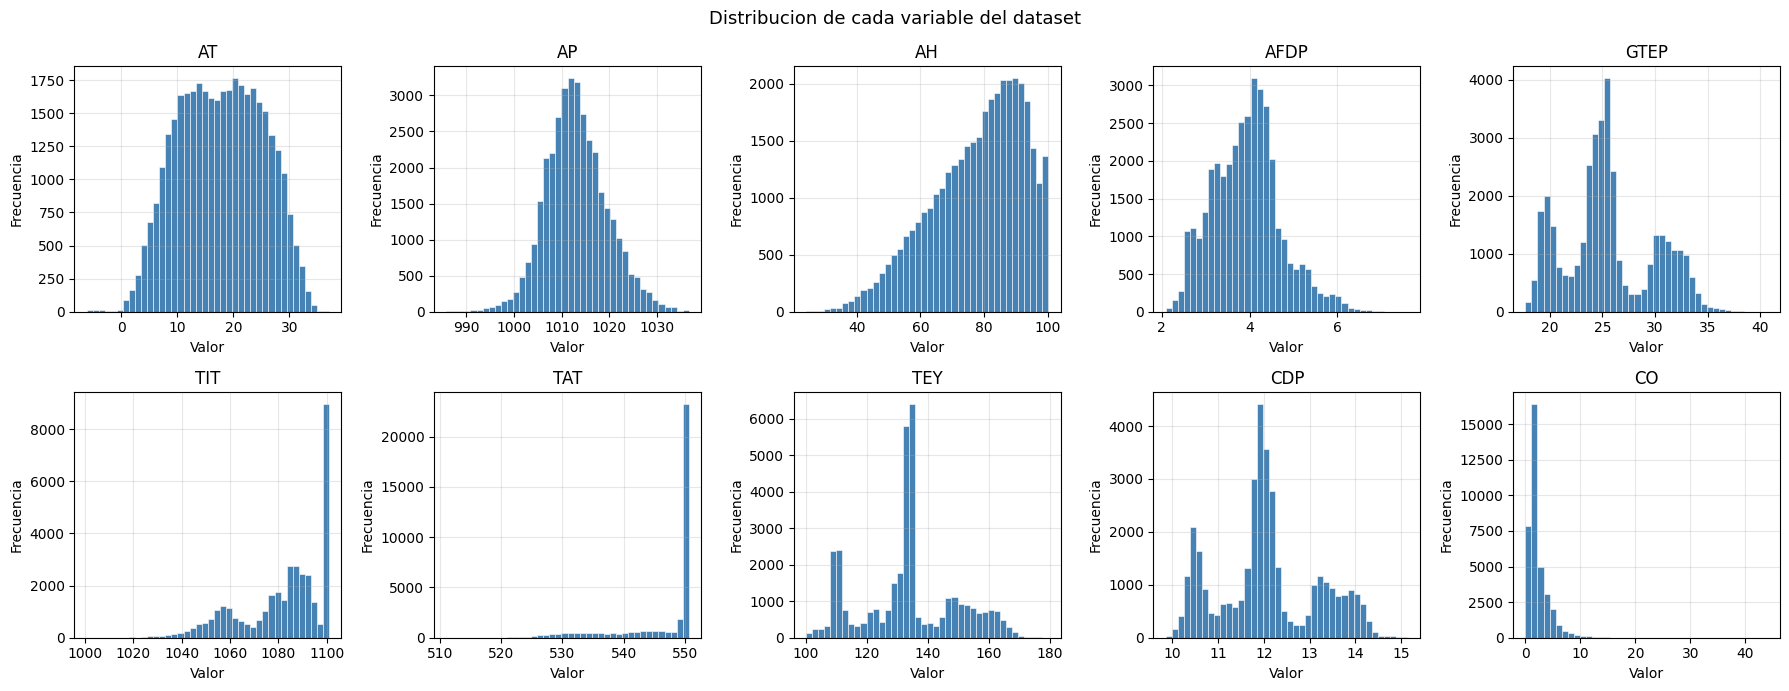

CO (variable objetivo): media=2.372  std=2.263  min=0.000  max=44.103


In [ ]:
# ── 1. Distribuciones de todas las variables ──────────────────────────────
# Analogo a graficar muestras del dataset en el Cuadernillo 01
# Aqui mostramos la distribucion de cada variable numerica

columnas_plot = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(columnas_plot):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribucion de cada variable del dataset', fontsize=13)
plt.tight_layout()
plt.show()
print('CO (variable objetivo): media={:.3f}  std={:.3f}  min={:.3f}  max={:.3f}'.format(
    df['CO'].mean(), df['CO'].std(), df['CO'].min(), df['CO'].max()))

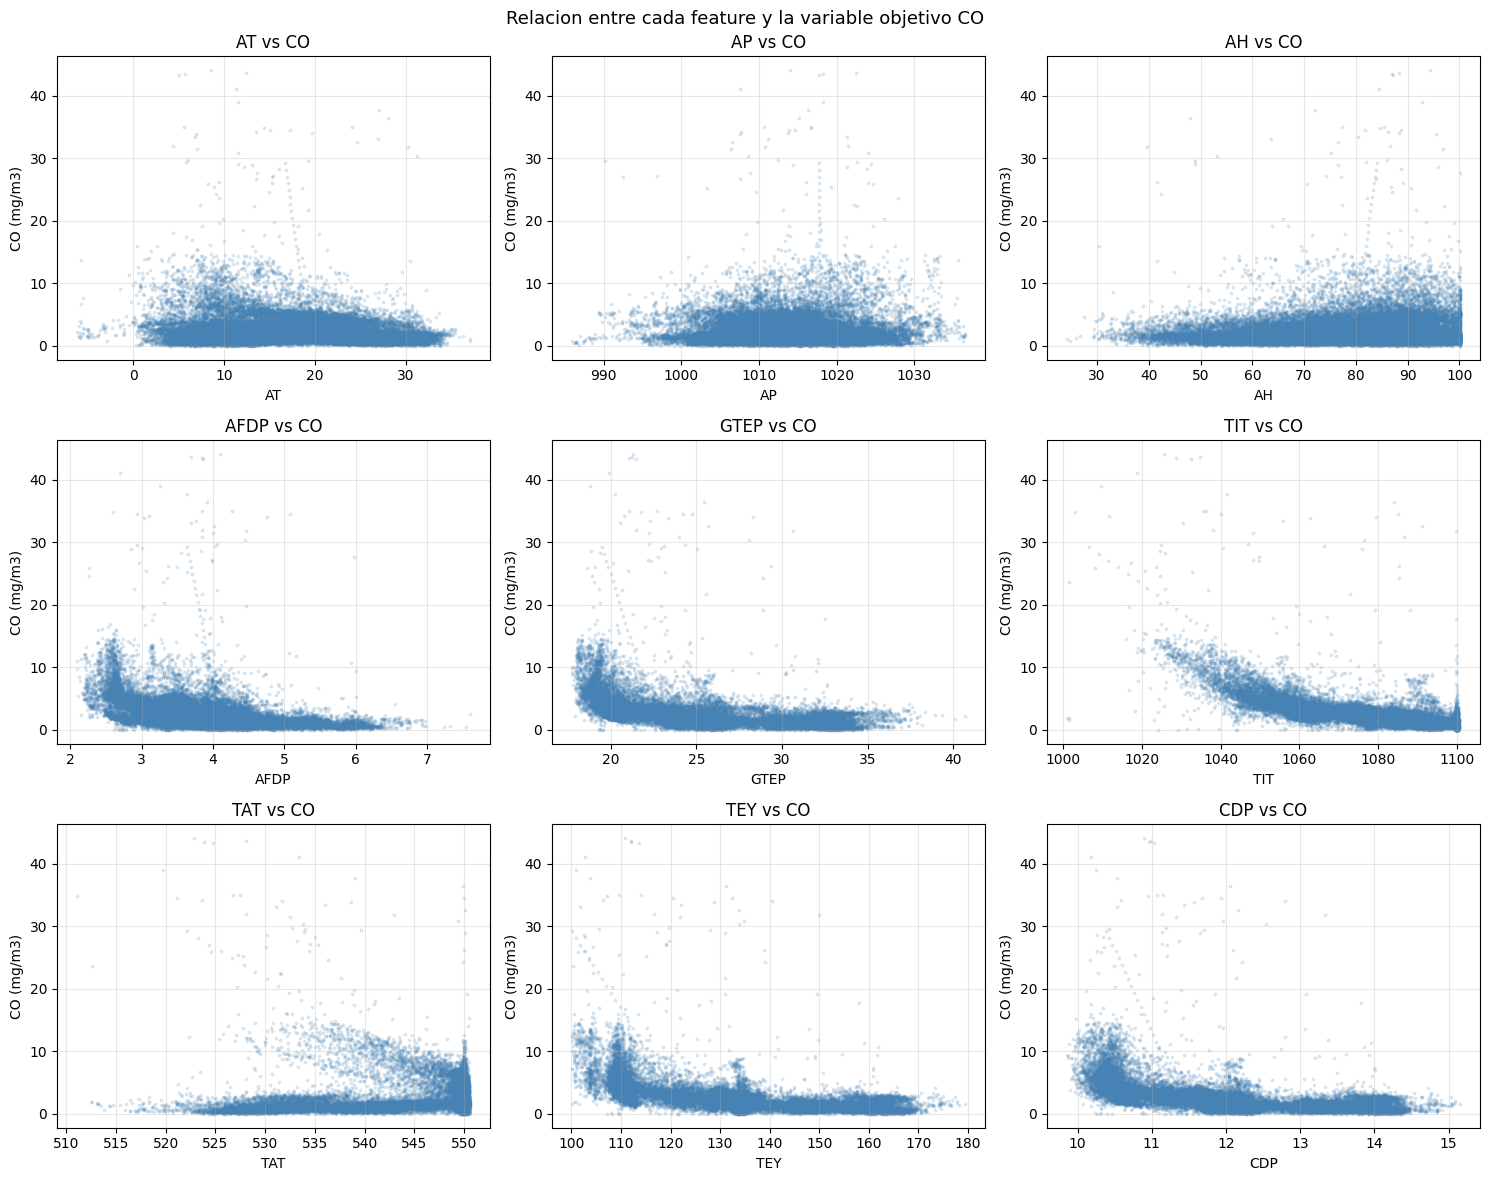

In [ ]:
# ── 2. Scatter plots: cada feature vs CO (variable objetivo) ──────────────
# Muestra la relacion individual entre cada sensor y las emisiones de CO
# Si los puntos forman una tendencia clara, esa variable aporta informacion

features_plot = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    axes[i].scatter(df[feat], df['CO'], alpha=0.15, s=3, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('CO (mg/m3)')
    axes[i].set_title(f'{feat} vs CO')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Relacion entre cada feature y la variable objetivo CO', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento de Datos

### 3.1 Separacion de features y target

Se separan las variables de entrada `X` (los 9 sensores operativos) de la variable objetivo `y` (CO en mg/m3).

Se excluyen del vector de entrada las columnas `CO` (es el target), `NOX` (es otra variable objetivo que no se predice en este laboratorio) y `ANO` (es un identificador temporal, no una variable operativa del sensor).

El resultado son arrays NumPy: `X` de forma `(36733, 9)` e `y` de forma `(36733,)`.

In [ ]:
features = ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
target   = 'CO'

X = df[features].values
y = df[target].values

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target):   {y.shape}")
print(f"\nFeatures utilizadas: {features}")
print(f"Variable objetivo:   {target}")

Shape de X (features): (36733, 9)
Shape de y (target):   (36733,)

Features utilizadas: ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
Variable objetivo:   CO


### 3.2 Division en Train y Test

Se divide el dataset en 80% para entrenamiento y 20% para prueba.

**Por que dividir?**  
El modelo solo aprende con los datos de entrenamiento. El conjunto de test nunca se usa para ajustar los pesos; unicamente sirve para medir que tan bien generaliza el modelo a datos que no vio durante el entrenamiento. Si evaluaramos con los mismos datos con los que entrenamos, el resultado seria artificialmente optimista y no reflejaria el rendimiento real.

`random_state=42` fija la semilla aleatoria para que la division sea reproducible.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} muestras  ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 29386 muestras (80%)
Test:  7347 muestras  (20%)


### 3.3 Normalizacion manual (media y desviacion estandar)

En los cuadernillos anteriores la normalizacion se realiza de dos maneras:

- **Division por 255:** para imagenes MNIST cuyos pixeles estan en el rango 0-255, se divide directamente entre 255 para llevarlos al rango 0-1. Ejemplo en los cuadernillos: `X_train = x_2[:60000] / 255.`
- **Formula manual (mu, sigma):** para datos tabulares con variables en escalas distintas, se calcula la media (`mu`) y la desviacion estandar (`sigma`) de cada columna con NumPy y se aplica la formula: `X_norm = (X - mu) / sigma`

En este laboratorio se usa la **formula manual**, que es el metodo que corresponde a datos con escalas muy diferentes (temperaturas, presiones, humedades).

**Regla critica:** `mu` y `sigma` se calculan **unicamente con los datos de entrenamiento** y se aplican tanto a train como a test con esos mismos valores. Si se calcularan incluyendo el test, se estaria filtrando informacion del futuro al modelo.

**Por que normalizar el target `y` tambien?**  
Las emisiones de CO tienen valores en una escala distinta a la de las features normalizadas. Normalizar `y` estabiliza los gradientes del SGD durante el entrenamiento. Al evaluar, se deshace la normalizacion con la formula inversa: `y_orig = y_norm * sigma_y + mu_y`.

In [ ]:
# normalizacion y split — igual que en los cuadernillos anteriores pero con formula manual

# Calculamos mu y sigma SOLO con los datos de entrenamiento
# El mismo valor se aplicara luego al test para no filtrar informacion
mu_X    = X_train.mean(axis=0)   # media de cada columna — shape (9,)
sigma_X = X_train.std(axis=0)    # desviacion estandar de cada columna — shape (9,)

# Aplicamos la formula: z = (x - mu) / sigma
# Esta es la misma logica que X_train / 255. en MNIST, pero para datos tabulares
X_train = (X_train - mu_X) / sigma_X
X_test  = (X_test  - mu_X) / sigma_X   # mismos mu y sigma del train

# Normalizacion del target (CO)
mu_y    = y_train.mean()
sigma_y = y_train.std()

y_train = (y_train - mu_y) / sigma_y
y_test  = (y_test  - mu_y) / sigma_y

print("Normalizacion completada.")
print(f"mu_X (primeras 3 features): {mu_X[:3].round(3)}")
print(f"sigma_X (primeras 3 features): {sigma_X[:3].round(3)}")
print(f"mu_y  (CO): {mu_y:.4f}  sigma_y (CO): {sigma_y:.4f}")
print(f"\nVerificacion — media de X_train[:,0] despues de normalizar: {X_train[:,0].mean():.4f}  (debe ser ~0)")
print(f"Verificacion — std  de X_train[:,0] despues de normalizar: {X_train[:,0].std():.4f}   (debe ser ~1)")

Normalizacion completada.
mu_X (primeras 3 features): [  17.717 1013.035   77.952]
sigma_X (primeras 3 features): [ 7.429  6.438 14.427]
mu_y  (CO): 2.3739  sigma_y (CO): 2.2450

Verificacion — media de X_train[:,0] despues de normalizar: -0.0000  (debe ser ~0)
Verificacion — std  de X_train[:,0] despues de normalizar: 1.0000   (debe ser ~1)


---
## 4. Dataset y DataLoader
### (Aplicacion del Cuadernillo 03)

### 4.1 Clase Dataset personalizada

En el Cuadernillo 03 se aprendio a encapsular los datos en una clase que herede de `torch.utils.data.Dataset`. Esta clase debe implementar tres metodos obligatorios:

- `__init__`: constructor donde se almacenan los datos y se convierten a tensores PyTorch.
- `__len__`: devuelve el numero total de muestras. El `DataLoader` lo usa para saber cuantos batches generar.
- `__getitem__`: devuelve una muestra especifica dado un indice. El `DataLoader` llama a este metodo para armar cada batch.

**Por que `.float()` en lugar de `.long()`?**  
En los cuadernillos anteriores el target se convirtio a `.long()` (entero) porque se trataba de clasificacion y el indice de la clase debe ser entero. En regresion, el target es un valor continuo (CO en mg/m3), por lo tanto debe ser `.float()`. La funcion de perdida `MSELoss` opera sobre tensores de tipo `float32` y lanzara un error si recibe tipos distintos.

In [ ]:
# Clase Dataset personalizada para regresion
# Hereda de torch.utils.data.Dataset, la clase madre de PyTorch para datasets
class TurbinaDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        # Convertimos los arrays NumPy a tensores PyTorch de tipo float32
        # En regresion tanto X como y son float, a diferencia de clasificacion
        # donde y es long (entero que representa la clase)
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        # El DataLoader necesita saber cuantas muestras tiene el dataset
        # para calcular el numero de batches por epoca
        return len(self.X)

    def __getitem__(self, ix):
        # Devuelve el par (features, target) de la muestra en el indice ix
        # El DataLoader llama a este metodo para construir cada batch
        return self.X[ix], self.y[ix]


dataset_train = TurbinaDataset(X_train, y_train)
dataset_test  = TurbinaDataset(X_test,  y_test)

print(f"Tamano dataset train: {len(dataset_train)} muestras")
print(f"Tamano dataset test:  {len(dataset_test)} muestras")

# Verificamos que una muestra tiene la forma y tipo correctos
x_ej, y_ej = dataset_train[0]
print(f"\nEjemplo muestra — X shape: {x_ej.shape}, y shape: {y_ej.shape}")
print(f"Ejemplo muestra — X dtype: {x_ej.dtype}, y dtype: {y_ej.dtype}")

Tamano dataset train: 29386 muestras
Tamano dataset test:  7347 muestras

Ejemplo muestra — X shape: torch.Size([9]), y shape: torch.Size([])
Ejemplo muestra — X dtype: torch.float32, y dtype: torch.float32


### 4.2 DataLoader

El `DataLoader` recibe un objeto `Dataset` y se encarga de iterar los datos en batches durante el entrenamiento. Es la herramienta central del Cuadernillo 03.

**Parametros clave:**

- `batch_size=256`: en cada paso del bucle de entrenamiento se calculan los gradientes sobre 256 muestras simultaneamente. Esto es el algoritmo *mini-batch gradient descent*. Es mas eficiente que calcular con una sola muestra a la vez (SGD puro) y mas practico que usar todas las muestras a la vez cuando el dataset es grande.
- `shuffle=True` en train: al inicio de cada epoca, el `DataLoader` mezcla aleatoriamente el orden de las muestras. Esto evita que el modelo aprenda el orden en que aparecen los datos, lo que mejora la generalizacion.
- `shuffle=False` en test: no se necesita mezclar para evaluar. Se mantiene el orden original para una evaluacion consistente.

In [ ]:
BATCH_SIZE = 256

dataloader = {
    'train': torch.utils.data.DataLoader(
        dataset_train,
        batch_size=BATCH_SIZE,
        shuffle=True
    ),
    'test': torch.utils.data.DataLoader(
        dataset_test,
        batch_size=BATCH_SIZE,
        shuffle=False
    )
}

# Verificamos que el DataLoader entrega batches con la forma esperada
x_batch, y_batch = next(iter(dataloader['train']))
print(f"Forma del batch de entrada X: {x_batch.shape}  — (batch_size, n_features)")
print(f"Forma del batch de target  y: {y_batch.shape}  — (batch_size,)")

Forma del batch de entrada X: torch.Size([256, 9])  — (batch_size, n_features)
Forma del batch de target  y: torch.Size([256])  — (batch_size,)


---
## 5. Definicion del Modelo
### (Aplicacion del Cuadernillo 02)

En el Cuadernillo 02 se aprendieron dos formas de definir un modelo en PyTorch: con `torch.nn.Sequential` y con una clase personalizada que herede de `torch.nn.Module`. Se usa `torch.nn.Module` porque ofrece mayor flexibilidad para controlar exactamente el flujo de datos en el metodo `forward`, tal como se hizo con `ModeloPersonalizado` en dicho cuadernillo.

### Arquitectura del Perceptron Multicapa (MLP) para Regresion

```
Entrada: 9 features  (AT, AP, AH, AFDP, GTEP, TIT, TAT, TEY, CDP)
    |
    v
Linear(9 -> 64)   +  ReLU
    |
    v
Linear(64 -> 32)  +  ReLU
    |
    v
Linear(32 -> 1)              <- salida lineal, sin activacion
    |
    v
Salida: 1 valor continuo (prediccion de CO en mg/m3)
```

**Por que la capa de salida tiene 1 neurona sin activacion?**  
En un problema de regresion se predice un valor continuo, no una clase. La capa de salida debe poder producir cualquier numero real, lo que se logra con una transformacion lineal sin restriccion. Aplicar Sigmoid acotaria la salida entre 0 y 1, lo cual es incorrecto para predecir mg/m3. Aplicar Softmax produciria una distribucion de probabilidades, que tampoco corresponde a regresion. La salida lineal es la unica apropiada.

**Por que ReLU en las capas ocultas?**  
Sin funciones de activacion, la red seria equivalente a una sola transformacion lineal, sin importar cuantas capas tenga. `ReLU(x) = max(0, x)` introduce no-linealidad, lo que permite a la red aprender patrones complejos, tal como se explico en el Cuadernillo 02.

In [ ]:
# Definicion del modelo MLP para regresion
# Se hereda de torch.nn.Module, igual que ModeloPersonalizado en el Cuadernillo 02
class MLPRegresion(torch.nn.Module):

    def __init__(self, D_in, H1, H2, D_out=1):
        """
        D_in  : numero de features de entrada (9 sensores)
        H1    : numero de neuronas en la primera capa oculta
        H2    : numero de neuronas en la segunda capa oculta
        D_out : numero de salidas (1 para regresion univariada)
        """
        # Se llama al constructor de la clase madre — obligatorio en PyTorch
        super(MLPRegresion, self).__init__()

        # Capas de la red — igual que en el Cuadernillo 02
        self.fc1  = torch.nn.Linear(D_in, H1)   # primera capa oculta
        self.relu = torch.nn.ReLU()              # activacion no-lineal
        self.fc2  = torch.nn.Linear(H1, H2)     # segunda capa oculta
        self.fc3  = torch.nn.Linear(H2, D_out)  # capa de salida lineal

    def forward(self, x):
        """
        Define el flujo de datos desde la entrada hasta la salida.
        PyTorch llama a este metodo automaticamente cuando se hace model(x).
        """
        x = self.relu(self.fc1(x))   # capa oculta 1 con activacion ReLU
        x = self.relu(self.fc2(x))   # capa oculta 2 con activacion ReLU
        x = self.fc3(x)              # capa de salida — SIN activacion (regresion)
        return x


# Instanciamos el modelo y lo movemos al dispositivo (GPU o CPU)
model = MLPRegresion(D_in=9, H1=64, H2=32, D_out=1).to(device)

print(model)
print(f"\nModelo cargado en: {device}")

# Prueba rapida: verificamos la forma de la salida
x_prueba = torch.randn(10, 9).to(device)
salida   = model(x_prueba)
print(f"\nForma de salida con 10 muestras: {salida.shape}")
print("Correcto: (10, 1) — 10 predicciones, 1 valor continuo por prediccion")

MLPRegresion(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Modelo cargado en: cuda

Forma de salida con 10 muestras: torch.Size([10, 1])
Correcto: (10, 1) — 10 predicciones, 1 valor continuo por prediccion


---
## 6. Funcion de Perdida y Optimizador
### (Aplicacion del Cuadernillo 02)

### Funcion de perdida: MSELoss

En el Cuadernillo 02 se uso `CrossEntropyLoss` porque el problema era de clasificacion. En regresion la funcion de perdida correcta es el **Error Cuadratico Medio** (MSE, *Mean Squared Error*):

```
MSE = (1/n) * suma( (y_predicho_i - y_real_i)^2 )
```

El MSE mide el promedio de los errores al cuadrado. Elevar al cuadrado penaliza mas los errores grandes y garantiza que la funcion sea siempre positiva y diferenciable, lo que permite calcular los gradientes.

### Optimizador: SGD (Descenso por Gradiente Estocastico)

Fiel al Cuadernillo 02 y al Cuadernillo 03, se usa `torch.optim.SGD`. En esos cuadernillos se uso `lr=0.8` para clasificacion con MNIST. Para este problema de regresion se usa una tasa de aprendizaje mas pequena (`lr=0.01`) porque la funcion MSE tiene gradientes de diferente magnitud que CrossEntropy, y una tasa muy alta puede hacer que el entrenamiento diverja.

El SGD actualiza los pesos en cada batch siguiendo la regla: `w = w - lr * gradiente`.

In [ ]:
# Funcion de perdida para REGRESION: Error Cuadratico Medio
# reduction='mean' (valor por defecto): calcula el promedio sobre el batch
criterion = torch.nn.MSELoss()

# Optimizador SGD — fiel al Cuadernillo 02 y Cuadernillo 03
# model.parameters() le pasa todos los tensores entrenables del modelo
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("Funcion de perdida:", criterion)
print("Optimizador:", optimizer)

Funcion de perdida: MSELoss()
Optimizador: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


---
## 7. Entrenamiento con Checkpoints
### (Integracion de los Cuadernillos 02, 03 y 04)

La funcion `fit` integra todo lo aprendido en los tres cuadernillos. Su estructura esta basada directamente en la funcion `fit` del **Cuadernillo 04**, adaptada a regresion.

### Lo que se registra por epoca

Tal como el Cuadernillo 04 registra `train_loss`, `val_loss`, `train_acc` y `val_acc` por epoca, aqui se registran:

- `train_loss` y `val_loss`: la perdida MSE promedio sobre el conjunto de entrenamiento y de test respectivamente. Son la perdida **en escala normalizada**, la misma con la que se entrena el modelo.
- `train_mse` y `val_mse`: el MSE calculado en las **unidades originales del problema (mg/m3)**, deshaciendo la normalizacion con la formula inversa: `y_orig = y_norm * sigma_y + mu_y`. Estos valores son interpretables directamente: representan el error cuadratico medio en mg/m3.

El analogo de `train_acc` vs `val_acc` del Cuadernillo 04 en este problema de regresion es `train_mse` vs `val_mse`. Comparar ambas curvas permite detectar si el modelo esta aprendiendo o memorizando:

- Si `train_mse` y `val_mse` descienden juntos: el modelo esta aprendiendo.
- Si `train_mse` sigue bajando pero `val_mse` sube de forma sostenida: el modelo esta memorizando los datos de entrenamiento (*overfitting*).

### Patron Checkpoint (Cuadernillo 04)

El Cuadernillo 04 guarda el modelo solo cuando `val_acc` mejora (supera al mejor registrado). Aqui se aplica el mismo patron pero guardando cuando `val_loss` mejora (es menor que la mejor registrada). Al finalizar, se carga el `state_dict` del mejor checkpoint, no el del ultimo epoch.

In [ ]:
def fit(model, dataloader, epochs=300, PATH="./mejor_modelo_turbina.pt"):
    """
    Entrena el modelo y guarda el checkpoint del mejor epoch (menor val_loss).
    Estructura basada en la funcion fit del Cuadernillo 04, adaptada a regresion.

    Parametros
    ----------
    model      : instancia de MLPRegresion
    dataloader : dict con claves 'train' y 'test', cada una con su DataLoader
    epochs     : numero de epocas de entrenamiento
    PATH       : ruta donde se guarda el state_dict del mejor modelo

    Retorna
    -------
    historia : dict con train_loss, val_loss, train_mse, val_mse por epoca
    """
    model.to(device)

    # Registramos cuatro metricas por epoca, igual que el Cuadernillo 04
    # train_loss / val_loss : perdida MSE en escala normalizada (con la que entrena el modelo)
    # train_mse  / val_mse  : MSE en escala original mg/m3 (interpretable)
    historia = {'train_loss': [], 'val_loss': [], 'train_mse': [], 'val_mse': []}

    mejor_val_loss = float('inf')   # analogo a best_acc = 0 del Cuadernillo 04

    for epoch in range(1, epochs + 1):

        # ----------------------------------------------------------------
        # FASE DE ENTRENAMIENTO
        # model.train() pone la red en modo entrenamiento
        # ----------------------------------------------------------------
        model.train()
        train_loss_ep = []
        train_preds   = []
        train_reales  = []

        bar = tqdm(dataloader['train'], desc=f"Epoch {epoch}/{epochs} [train]")
        for X, y in bar:
            X, y = X.to(device), y.to(device)

            # Paso 1 — Forward
            y_hat = model(X).squeeze(1)

            # Paso 2 — Loss (MSE normalizado)
            loss = criterion(y_hat, y)
            train_loss_ep.append(loss.item())

            # Guardamos predicciones y reales para calcular MSE en escala original
            train_preds.append(y_hat.detach().cpu().numpy())
            train_reales.append(y.cpu().numpy())

            # Paso 3 — Zero grad
            optimizer.zero_grad()

            # Paso 4 — Backward
            loss.backward()

            # Paso 5 — Step
            optimizer.step()

            bar.set_description(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss_ep):.5f}")

        # ----------------------------------------------------------------
        # FASE DE VALIDACION
        # model.eval() pone la red en modo inferencia
        # ----------------------------------------------------------------
        model.eval()
        val_loss_ep = []
        val_preds   = []
        val_reales  = []

        bar = tqdm(dataloader['test'], desc=f"Epoch {epoch}/{epochs} [val]  ")
        with torch.no_grad():
            for X, y in bar:
                X, y = X.to(device), y.to(device)
                y_hat = model(X).squeeze(1)
                loss  = criterion(y_hat, y)
                val_loss_ep.append(loss.item())
                val_preds.append(y_hat.cpu().numpy())
                val_reales.append(y.cpu().numpy())
                bar.set_description(f"Epoch {epoch}/{epochs} val_loss {np.mean(val_loss_ep):.5f}")

        # ----------------------------------------------------------------
        # Calculo de metricas en escala original (mg/m3)
        # Se deshace la normalizacion del target para obtener valores reales
        # ----------------------------------------------------------------
        train_preds_orig  = np.concatenate(train_preds) * sigma_y + mu_y
        train_reales_orig = np.concatenate(train_reales) * sigma_y + mu_y
        val_preds_orig    = np.concatenate(val_preds) * sigma_y + mu_y
        val_reales_orig   = np.concatenate(val_reales) * sigma_y + mu_y

        train_mse_orig = mean_squared_error(train_reales_orig, train_preds_orig)
        val_mse_orig   = mean_squared_error(val_reales_orig,   val_preds_orig)

        # Promedios por epoca
        train_loss_media = np.mean(train_loss_ep)
        val_loss_media   = np.mean(val_loss_ep)

        historia['train_loss'].append(train_loss_media)
        historia['val_loss'].append(val_loss_media)
        historia['train_mse'].append(train_mse_orig)
        historia['val_mse'].append(val_mse_orig)

        # ----------------------------------------------------------------
        # CHECKPOINT — analogo al patron del Cuadernillo 04
        # Cuadernillo 04: guarda cuando val_acc > best_acc
        # Aqui:          guarda cuando val_loss < mejor_val_loss
        # ----------------------------------------------------------------
        if val_loss_media < mejor_val_loss:
            mejor_val_loss = val_loss_media
            torch.save(model.state_dict(), PATH)
            if epoch % 10 == 0 or epoch == 1: # Print every 10 epochs or on the first epoch
                print(f"Epoch {epoch}/{epochs} loss {train_loss_media:.5f} val_loss {val_loss_media:.5f} train_mse {train_mse_orig:.4f} val_mse {val_mse_orig:.4f} <- Mejor modelo guardado")
        else:
            if epoch % 10 == 0 or epoch == 1: # Print every 10 epochs or on the first epoch
                print(f"Epoch {epoch}/{epochs} loss {train_loss_media:.5f} val_loss {val_loss_media:.5f} train_mse {train_mse_orig:.4f} val_mse {val_mse_orig:.4f}")

    # Al finalizar, cargamos el mejor checkpoint — igual que el Cuadernillo 04
    print(f"\nEntrenamiento finalizado. Cargando mejor modelo (val_loss: {mejor_val_loss:.5f})")
    model.load_state_dict(torch.load(PATH))

    return historia

In [ ]:
# Reinstanciamos el modelo para asegurar pesos inicializados desde cero
model     = MLPRegresion(D_in=9, H1=64, H2=32, D_out=1).to(device)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

CHECKPOINT_PATH = './mejor_modelo_turbina.pt'

historia = fit(model, dataloader, epochs=300, PATH=CHECKPOINT_PATH)

Epoch 1/300 val_loss 0.57440: 100%|██████████| 29/29 [00:00<00:00, 235.07it/s]


Epoch 1/300 loss 0.74037 val_loss 0.57440 train_mse 3.7361 val_mse 2.9133 <- Mejor modelo guardado


Epoch 10/300 val_loss 0.34116: 100%|██████████| 29/29 [00:00<00:00, 250.26it/s]


Epoch 10/300 loss 0.32917 val_loss 0.34116 train_mse 1.6605 val_mse 1.7293 <- Mejor modelo guardado


Epoch 20/300 val_loss 0.32856: 100%|██████████| 29/29 [00:00<00:00, 240.47it/s]


...

Epoch 280/300 loss 0.24002 val_loss 0.25541 train_mse 1.2076 val_mse 1.2950


Epoch 290/300 val_loss 0.24630: 100%|██████████| 29/29 [00:00<00:00, 219.83it/s]


Epoch 290/300 loss 0.23790 val_loss 0.24630 train_mse 1.2000 val_mse 1.2486


Epoch 300/300 val_loss 0.25657: 100%|██████████| 29/29 [00:00<00:00, 226.89it/s]


Epoch 300/300 loss 0.23653 val_loss 0.25657 train_mse 1.1916 val_mse 1.3010

Entrenamiento finalizado. Cargando mejor modelo (val_loss: 0.24392)


---
## 8. Curvas de Aprendizaje

Se grafican dos comparaciones lado a lado, tal como el Cuadernillo 04 reporta tanto la perdida como la precision por separado:

**Grafico izquierdo — Loss (MSE normalizado):**  
Muestra la evolucion de la funcion de perdida que el modelo minimizo durante el entrenamiento. Permite ver la velocidad de convergencia y detectar si hay overfitting (cuando `val_loss` sube mientras `train_loss` baja).

**Grafico derecho — MSE en escala original (mg/m3):**  
Es el analogo al grafico de `accuracy` del Cuadernillo 04, pero para regresion. Muestra el error en las unidades reales del problema, comparando el error sobre datos de entrenamiento vs datos de test. Si ambas curvas descienden juntas, el modelo generaliza. Si `train_mse` es mucho menor que `val_mse` y la brecha crece con las epocas, hay overfitting.

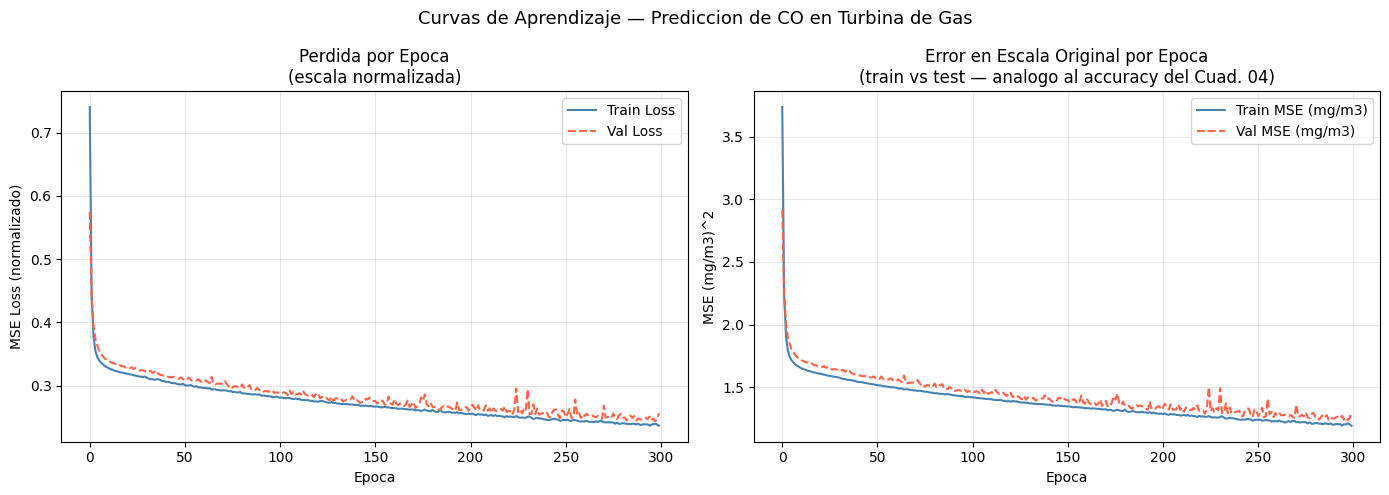

Train loss final:  0.23653
Val loss final:    0.25657
Train MSE final:   1.1916 (mg/m3)^2
Val MSE final:     1.3010 (mg/m3)^2
Mejor val_loss:    0.24392  (epoch 298)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grafico izquierdo: Loss (MSE normalizado) ──────────────────────────
axes[0].plot(historia['train_loss'], label='Train Loss', color='steelblue', linewidth=1.5)
axes[0].plot(historia['val_loss'],   label='Val Loss',   color='tomato', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE Loss (normalizado)')
axes[0].set_title('Perdida por Epoca\n(escala normalizada)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Grafico derecho: MSE en unidades reales (mg/m3) ───────────────────
# Analogo al grafico de accuracy del Cuadernillo 04, pero para regresion
# Aqui se compara el error sobre datos de entrenamiento vs datos de test
axes[1].plot(historia['train_mse'], label='Train MSE (mg/m3)', color='steelblue', linewidth=1.5)
axes[1].plot(historia['val_mse'],   label='Val MSE (mg/m3)',   color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MSE (mg/m3)^2')
axes[1].set_title('Error en Escala Original por Epoca\n(train vs test — analogo al accuracy del Cuad. 04)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Prediccion de CO en Turbina de Gas', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Train loss final:  {historia['train_loss'][-1]:.5f}")
print(f"Val loss final:    {historia['val_loss'][-1]:.5f}")
print(f"Train MSE final:   {historia['train_mse'][-1]:.4f} (mg/m3)^2")
print(f"Val MSE final:     {historia['val_mse'][-1]:.4f} (mg/m3)^2")
print(f"Mejor val_loss:    {min(historia['val_loss']):.5f}  (epoch {historia['val_loss'].index(min(historia['val_loss']))+1})")

---
## 9. Evaluacion Final del Modelo

Se evalua el mejor modelo (cargado automaticamente al final de `fit`) sobre el conjunto de test.

**Por que no se usa Accuracy en regresion?**  
El Accuracy mide la proporcion de predicciones exactamente correctas. En clasificacion tiene sentido porque las predicciones son categorias discretas. En regresion se predice un valor continuo (CO en mg/m3), por lo que la probabilidad de acertar exactamente es practicamente cero. Las metricas apropiadas son:

- **MSE** — Error Cuadratico Medio. Unidades al cuadrado del target.
- **RMSE** — Raiz del MSE. Misma unidad que CO (mg/m3), directamente interpretable como el error promedio del modelo.
- **R2** — Coeficiente de Determinacion. Fraccion de la varianza total del target que explica el modelo. R2 = 1.0 es prediccion perfecta; R2 = 0.0 equivale a predecir siempre la media del target.

**Por que deshacer la normalizacion?**  
El modelo fue entrenado con `y` normalizado. Las predicciones que produce estan en esa escala. Para calcular metricas interpretables en mg/m3, se aplica la formula inversa: `y_orig = y_norm * sigma_y + mu_y`.

In [ ]:
# Generamos predicciones con el modelo en modo eval
model.eval()
model.to(device)
y_real_list = []
y_pred_list = []

with torch.no_grad():
    for X, y in dataloader['test']:
        X     = X.to(device)
        y_hat = model(X).squeeze(1)
        y_real_list.append(y.numpy())
        y_pred_list.append(y_hat.cpu().numpy())

y_real_norm = np.concatenate(y_real_list)
y_pred_norm = np.concatenate(y_pred_list)

# Deshacemos la normalizacion con la formula inversa: y_orig = y_norm * sigma_y + mu_y
# Esto es el inverso de (y - mu_y) / sigma_y aplicado al entrenar
y_real_orig = y_real_norm * sigma_y + mu_y
y_pred_orig = y_pred_norm * sigma_y + mu_y

# Metricas de regresion en escala original
mse  = mean_squared_error(y_real_orig, y_pred_orig)
rmse = np.sqrt(mse)
r2   = r2_score(y_real_orig, y_pred_orig)

print("=" * 52)
print("Metricas de Evaluacion Final — escala original")
print("=" * 52)
print(f"MSE:   {mse:.4f}  (mg/m3)^2")
print(f"RMSE:  {rmse:.4f}  mg/m3   — error promedio del modelo")
print(f"R2:    {r2:.4f}            — fraccion de varianza explicada")

Metricas de Evaluacion Final — escala original
MSE:   1.2362  (mg/m3)^2
RMSE:  1.1119  mg/m3   — error promedio del modelo
R2:    0.7727            — fraccion de varianza explicada


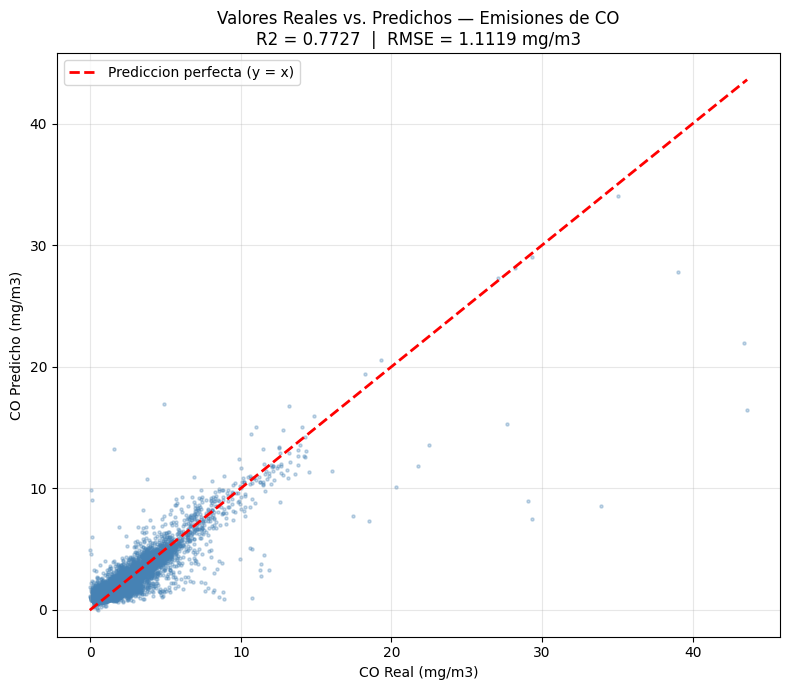

In [ ]:
# Grafico: Valores Reales vs. Predichos
# Si el modelo fuera perfecto, todos los puntos estarian sobre la linea diagonal y = x
# La dispersion alrededor de la diagonal refleja el error del modelo
plt.figure(figsize=(8, 7))
plt.scatter(y_real_orig, y_pred_orig, alpha=0.3, s=5, color='steelblue')

lim = [min(y_real_orig.min(), y_pred_orig.min()),
       max(y_real_orig.max(), y_pred_orig.max())]
plt.plot(lim, lim, 'r--', linewidth=2, label='Prediccion perfecta (y = x)')

plt.xlabel('CO Real (mg/m3)')
plt.ylabel('CO Predicho (mg/m3)')
plt.title(f'Valores Reales vs. Predichos — Emisiones de CO\nR2 = {r2:.4f}  |  RMSE = {rmse:.4f} mg/m3')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 10. Guardado y Carga del Modelo
### (Aplicacion del Cuadernillo 04)

En el Cuadernillo 04 se aprendio que la forma recomendada de guardar un modelo en PyTorch es guardando unicamente el `state_dict` (los pesos), no el modelo completo. Las razones son:

- Es mas eficiente en almacenamiento.
- Es mas portable entre versiones de PyTorch.
- Para cargarlo solo se necesita una instancia del modelo con la misma arquitectura, lo cual es la practica estandar.

El modelo ya fue guardado automaticamente durante el entrenamiento cada vez que mejoro la `val_loss`. Este bloque muestra explicitamente como guardar y cargar el `state_dict`, y verifica que el modelo cargado produce exactamente los mismos resultados.

In [ ]:
# Guardado manual del state_dict — igual que en el Cuadernillo 04
PATH_FINAL = './modelo_turbina_final.pt'
torch.save(model.state_dict(), PATH_FINAL)
print(f"Modelo guardado en: {PATH_FINAL}")

# Inspeccionamos el contenido del state_dict
# Cada clave corresponde a una capa; cada valor es un tensor con los pesos de esa capa
state = torch.load(PATH_FINAL)
print("\nCapas almacenadas en el state_dict:")
for nombre, tensor in state.items():
    print(f"  {nombre:15s} — shape: {tensor.shape}")

Modelo guardado en: ./modelo_turbina_final.pt

Capas almacenadas en el state_dict:
  fc1.weight      — shape: torch.Size([64, 9])
  fc1.bias        — shape: torch.Size([64])
  fc2.weight      — shape: torch.Size([32, 64])
  fc2.bias        — shape: torch.Size([32])
  fc3.weight      — shape: torch.Size([1, 32])
  fc3.bias        — shape: torch.Size([1])


In [ ]:
# Carga del modelo — igual que en el Cuadernillo 04
# Se necesita una instancia con la MISMA arquitectura para inyectar los pesos
modelo_cargado = MLPRegresion(D_in=9, H1=64, H2=32, D_out=1)
modelo_cargado.load_state_dict(torch.load(PATH_FINAL))
modelo_cargado.eval()

print("Modelo cargado correctamente.")

# Verificacion: el modelo cargado debe producir exactamente los mismos resultados
modelo_cargado.to(device)
y_pred_v2 = []
with torch.no_grad():
    for X, y in dataloader['test']:
        X = X.to(device)
        y_pred_v2.append(modelo_cargado(X).squeeze(1).cpu().numpy())

# Deshacemos la normalizacion con la formula inversa
y_pred_orig_v2 = np.concatenate(y_pred_v2) * sigma_y + mu_y
r2_v2 = r2_score(y_real_orig, y_pred_orig_v2)

print(f"R2 del modelo cargado:    {r2_v2:.4f}")
print(f"R2 del modelo original:   {r2:.4f}")
print(f"Resultados identicos:     {abs(r2_v2 - r2) < 1e-6}")

Modelo cargado correctamente.
R2 del modelo cargado:    0.7727
R2 del modelo original:   0.7727
Resultados identicos:     True


---
## 11. Resumen del Laboratorio

Este cuadernillo implemento el pipeline completo de redes neuronales con PyTorch para regresion, aplicando fielmente los conceptos de los tres cuadernillos anteriores:

| Paso | Herramienta PyTorch | Cuadernillo de origen |
|---|---|---|
| Encapsular los datos | `torch.utils.data.Dataset` | Cuadernillo 03 |
| Iterar en mini-batches | `torch.utils.data.DataLoader` | Cuadernillo 03 |
| Definir la arquitectura de la red | `torch.nn.Module` | Cuadernillo 02 |
| Funcion de perdida para regresion | `torch.nn.MSELoss` | Cuadernillo 02 |
| Algoritmo de optimizacion | `torch.optim.SGD` | Cuadernillo 02 y 03 |
| Bucle de entrenamiento | `model.train()`, `loss.backward()`, `optimizer.step()` | Cuadernillo 02 |
| Funcion fit con tqdm | `tqdm`, registro de train/val loss y train/val MSE | Cuadernillo 04 |
| Guardar el mejor modelo | `torch.save(model.state_dict(), PATH)` | Cuadernillo 04 |
| Cargar el mejor modelo | `model.load_state_dict(torch.load(PATH))` | Cuadernillo 04 |

---

### Diferencias clave entre Regresion y Clasificacion en PyTorch

| Aspecto | Clasificacion (cuadernillos anteriores) | Regresion (este laboratorio) |
|---|---|---|
| Neuronas en la capa de salida | N neuronas (una por clase) | 1 neurona |
| Activacion en la capa de salida | Ninguna (CrossEntropyLoss la incluye internamente) | Ninguna — salida lineal |
| Funcion de perdida | `CrossEntropyLoss` | `MSELoss` |
| Tipo del tensor target | `.long()` — entero que representa la clase | `.float()` — valor continuo |
| Normalizacion de los datos | Division por 255 (imagenes) | Formula manual: `(X - mu) / sigma` con NumPy |
| Metrica de seguimiento por epoca | `train_acc` vs `val_acc` | `train_mse` vs `val_mse` (en mg/m3) |
| Metrica final de evaluacion | Accuracy | RMSE, R2 |
| Activacion Sigmoid | Se usa en clasificacion binaria | No se usa — la salida es libre |

---

### Interpretacion de los resultados

Las curvas de aprendizaje muestran si el modelo esta generalizando o memorizando. Cuando `train_mse` y `val_mse` descienden juntos, el modelo aprende patrones reales del dataset. El R2 obtenido indica que fraccion de la variabilidad en las emisiones de CO explica la red neuronal usando unicamente las nueve variables operativas de los sensores.